# Phase 2 — Data Preprocessing & SMOTE Balancing

---
## Step 1 — Install & Import Libraries

In [ ]:
!pip install imbalanced-learn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Display settings
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 2 — Load Dataset

In [ ]:
df = pd.read_csv('creditcard.csv')

print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Class distribution:')
print(f'  Legitimate (0) : {(df.Class==0).sum():,}  ({(df.Class==0).mean()*100:.4f}%)')
print(f'  Fraud      (1) : {(df.Class==1).sum():,}   ({(df.Class==1).mean()*100:.4f}%)')

Dataset loaded: 284,807 rows x 31 columns
Class distribution:
  Legitimate (0) : 284,315  (99.8273%)
  Fraud      (1) : 492   (0.1727%)


---
## Step 3 — Feature Scaling

> **Why scale only `Amount` and `Time`?**
> - V1–V28 are already PCA-transformed and standardized.
> - `Amount` ranges from $0 to $25,691 — huge scale difference.
> - `Time` ranges from 0 to 172,792 seconds.
> - Unscaled features would dominate distance-based models (SVM, KNN) and slow down gradient descent.
>
> We use **StandardScaler** → transforms each feature to mean=0, std=1.

In [4]:
# Separate features and target
X = df.drop('Class', axis=1).copy()
y = df['Class'].copy()

# ---- Before scaling ----
print('BEFORE SCALING')
print('-' * 45)
print(f'Amount  — Mean: {X["Amount"].mean():>10.2f}  Std: {X["Amount"].std():>10.2f}')
print(f'Time    — Mean: {X["Time"].mean():>10.2f}  Std: {X["Time"].std():>10.2f}')
print(f'V1      — Mean: {X["V1"].mean():>10.4f}  Std: {X["V1"].std():>10.4f}  (already scaled)')

# ---- Apply StandardScaler to Amount and Time only ----
scaler = StandardScaler()
X[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])

print()
print('AFTER SCALING')
print('-' * 45)
print(f'Amount  — Mean: {X["Amount"].mean():>10.4f}  Std: {X["Amount"].std():>10.4f}')
print(f'Time    — Mean: {X["Time"].mean():>10.4f}  Std: {X["Time"].std():>10.4f}')
print(f'V1      — Mean: {X["V1"].mean():>10.4f}  Std: {X["V1"].std():>10.4f}  (unchanged)')
print()
print('StandardScaler applied to Amount and Time.')

BEFORE SCALING
---------------------------------------------
Amount  — Mean:      88.35  Std:     250.12
Time    — Mean:   94813.86  Std:   47488.15
V1      — Mean:     0.0000  Std:     1.9587  (already scaled)

AFTER SCALING
---------------------------------------------
Amount  — Mean:    -0.0000  Std:     1.0000
Time    — Mean:    -0.0000  Std:     1.0000
V1      — Mean:     0.0000  Std:     1.9587  (unchanged)

StandardScaler applied to Amount and Time.


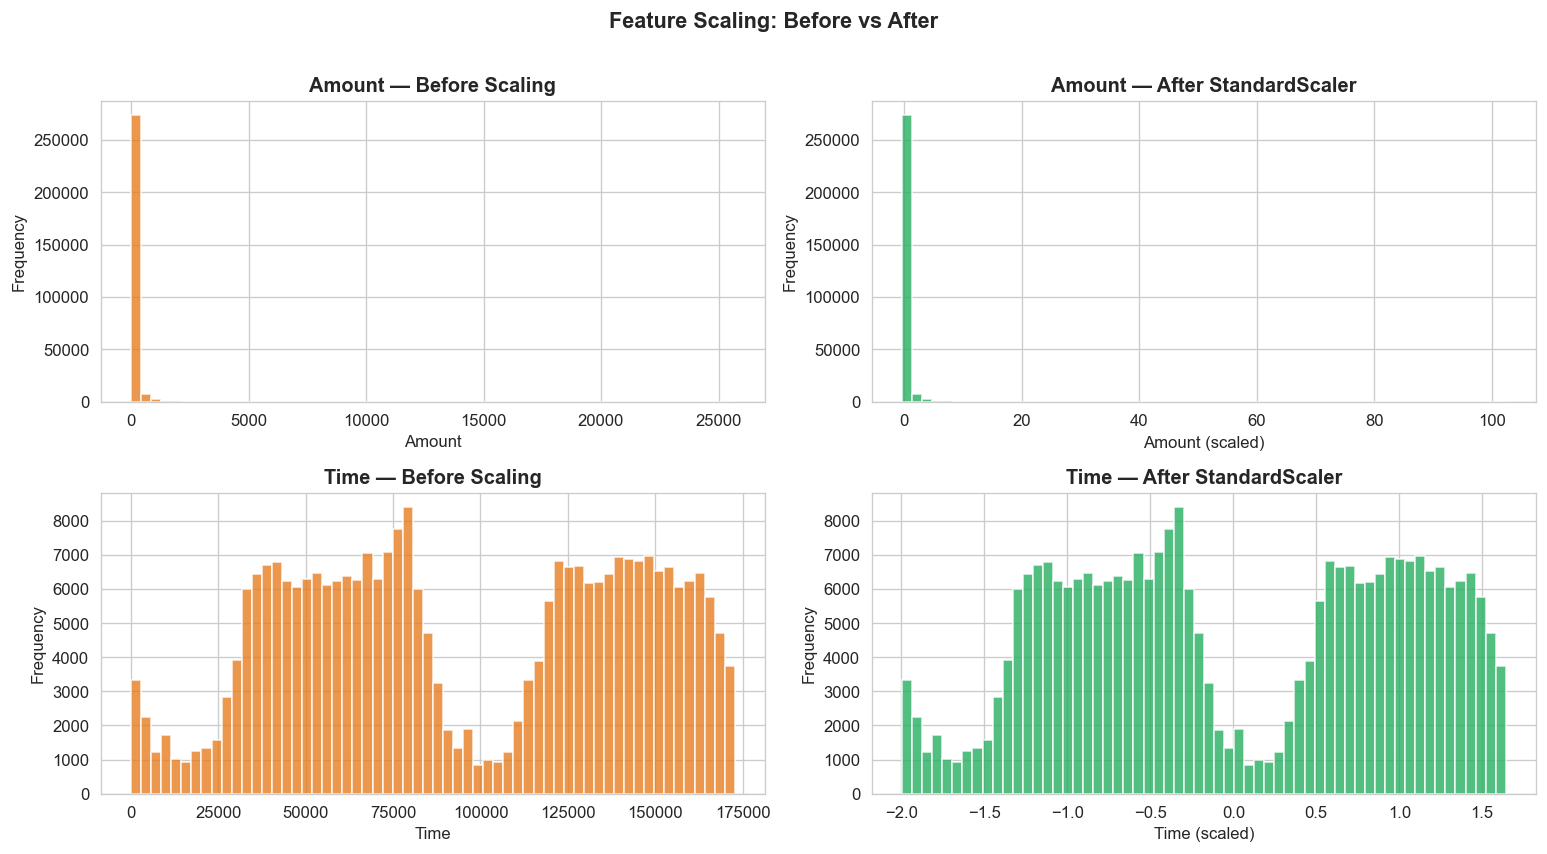

Plot saved: plot_09_scaling_before_after.png


In [5]:
# Visualize before vs after scaling
df_before = df[['Amount', 'Time']].copy()
df_after  = X[['Amount', 'Time']].copy()

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

for i, col in enumerate(['Amount', 'Time']):
    # Before
    axes[i][0].hist(df_before[col], bins=60, color='#e67e22', alpha=0.8, edgecolor='white')
    axes[i][0].set_title(f'{col} — Before Scaling', fontweight='bold')
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('Frequency')
    # After
    axes[i][1].hist(df_after[col], bins=60, color='#27ae60', alpha=0.8, edgecolor='white')
    axes[i][1].set_title(f'{col} — After StandardScaler', fontweight='bold')
    axes[i][1].set_xlabel(f'{col} (scaled)')
    axes[i][1].set_ylabel('Frequency')

plt.suptitle('Feature Scaling: Before vs After', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_09_scaling_before_after.png', bbox_inches='tight', dpi=150)
plt.show()
print('Plot saved: plot_09_scaling_before_after.png')

---
## Step 4 — Train / Test Split (80/20 Stratified)

In [6]:
# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserves class ratio in both splits
)

print('Train / Test Split Results')
print('=' * 50)
print(f'Training set   : {X_train.shape[0]:>7,} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  └ Legitimate : {(y_train==0).sum():>7,} ({(y_train==0).mean()*100:.4f}%)')
print(f'  └ Fraud      : {(y_train==1).sum():>7,}   ({(y_train==1).mean()*100:.4f}%)')
print()
print(f'Test set       : {X_test.shape[0]:>7,} rows ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'  └ Legitimate : {(y_test==0).sum():>7,} ({(y_test==0).mean()*100:.4f}%)')
print(f'  └ Fraud      : {(y_test==1).sum():>7,}    ({(y_test==1).mean()*100:.4f}%)')
print('=' * 50)
print('✓ Stratified split preserves ~0.17% fraud ratio in both sets.')
print('✓ Test set will NOT be touched by SMOTE (no data leakage).')

Train / Test Split Results
Training set   : 227,845 rows (80%)
  └ Legitimate : 227,451 (99.8271%)
  └ Fraud      :     394   (0.1729%)

Test set       :  56,962 rows (20%)
  └ Legitimate :  56,864 (99.8280%)
  └ Fraud      :      98    (0.1720%)
✓ Stratified split preserves ~0.17% fraud ratio in both sets.
✓ Test set will NOT be touched by SMOTE (no data leakage).


---
## Step 5 — SMOTE: Synthetic Minority Oversampling Technique

In [7]:
print('BEFORE SMOTE (training set):')
print(f'  Legitimate : {(y_train==0).sum():,}')
print(f'  Fraud      : {(y_train==1).sum():,}')
print(f'  Ratio      : 1 fraud per {(y_train==0).sum()//(y_train==1).sum():,} legitimate')
print()

# Apply SMOTE — only on training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('AFTER SMOTE (training set):')
print(f'  Legitimate : {(y_train_smote==0).sum():,}')
print(f'  Fraud      : {(y_train_smote==1).sum():,}')
print(f'  New rows added (synthetic fraud) : {(y_train_smote==1).sum() - (y_train==1).sum():,}')
print(f'  Total training rows : {len(X_train_smote):,}')
print()
print('Test set (unchanged):')
print(f'  Legitimate : {(y_test==0).sum():,}')
print(f'  Fraud      : {(y_test==1).sum():,}')

BEFORE SMOTE (training set):
  Legitimate : 227,451
  Fraud      : 394
  Ratio      : 1 fraud per 577 legitimate

AFTER SMOTE (training set):
  Legitimate : 227,451
  Fraud      : 227,451
  New rows added (synthetic fraud) : 227,057
  Total training rows : 454,902

Test set (unchanged):
  Legitimate : 56,864
  Fraud      : 98


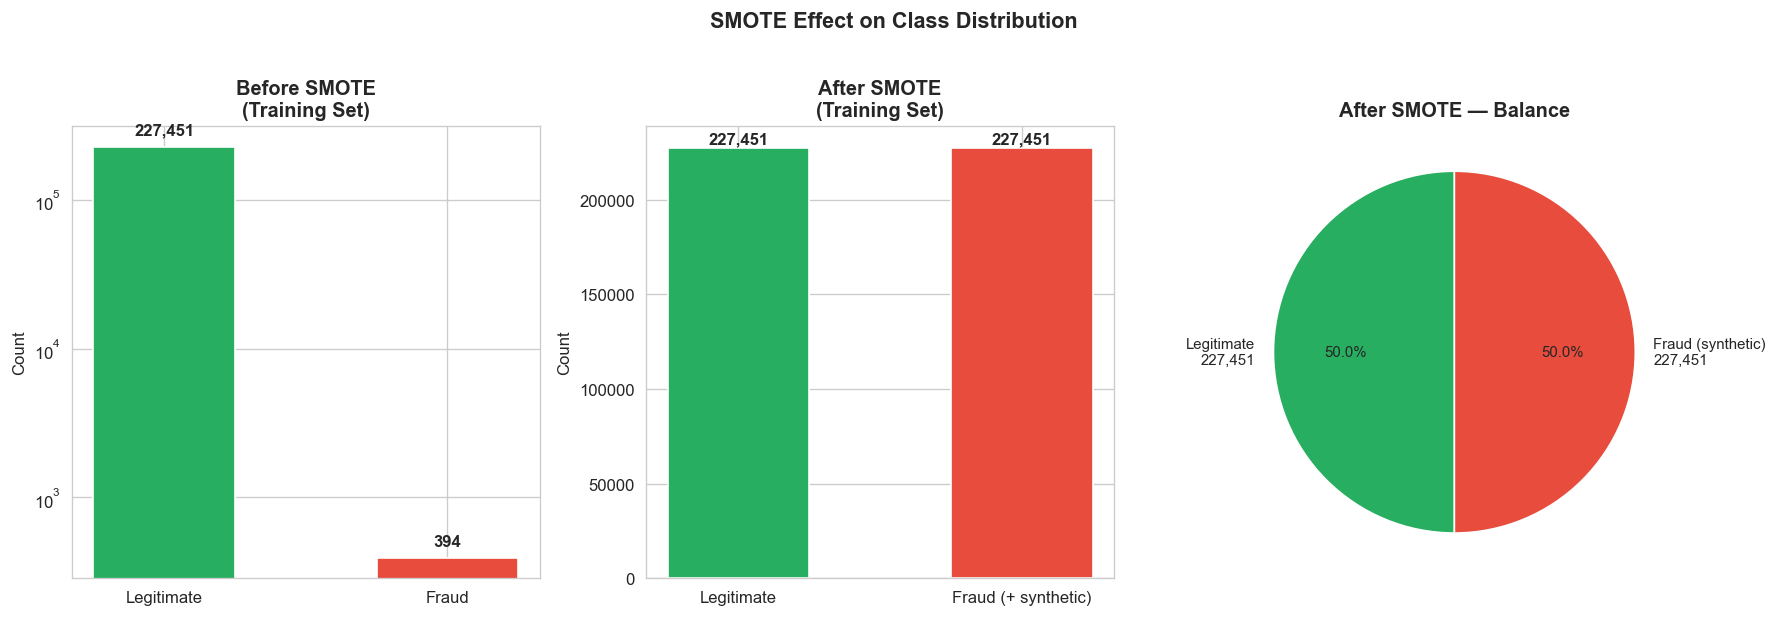

Plot saved: plot_10_smote_comparison.png


In [8]:
# Visualize before vs after SMOTE
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Before SMOTE ---
before_counts = y_train.value_counts()
colors = ['#27ae60', '#e74c3c']
bars = axes[0].bar(['Legitimate', 'Fraud'], before_counts.values,
                   color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Before SMOTE\n(Training Set)', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')
for bar, v in zip(bars, before_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.2,
                 f'{v:,}', ha='center', fontweight='bold', fontsize=10)

# --- After SMOTE ---
after_counts = pd.Series(y_train_smote).value_counts()
bars2 = axes[1].bar(['Legitimate', 'Fraud (+ synthetic)'], after_counts.values,
                    color=colors, edgecolor='white', width=0.5)
axes[1].set_title('After SMOTE\n(Training Set)', fontweight='bold')
axes[1].set_ylabel('Count')
for bar, v in zip(bars2, after_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000,
                 f'{v:,}', ha='center', fontweight='bold', fontsize=10)

# --- Pie after SMOTE ---
axes[2].pie(
    after_counts.values,
    labels=['Legitimate\n227,451', 'Fraud (synthetic)\n227,451'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 9}
)
axes[2].set_title('After SMOTE — Balance', fontweight='bold')

plt.suptitle('SMOTE Effect on Class Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_10_smote_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Plot saved: plot_10_smote_comparison.png')

---
## Step 6 — Visualize SMOTE Synthetic Samples (2D PCA View)


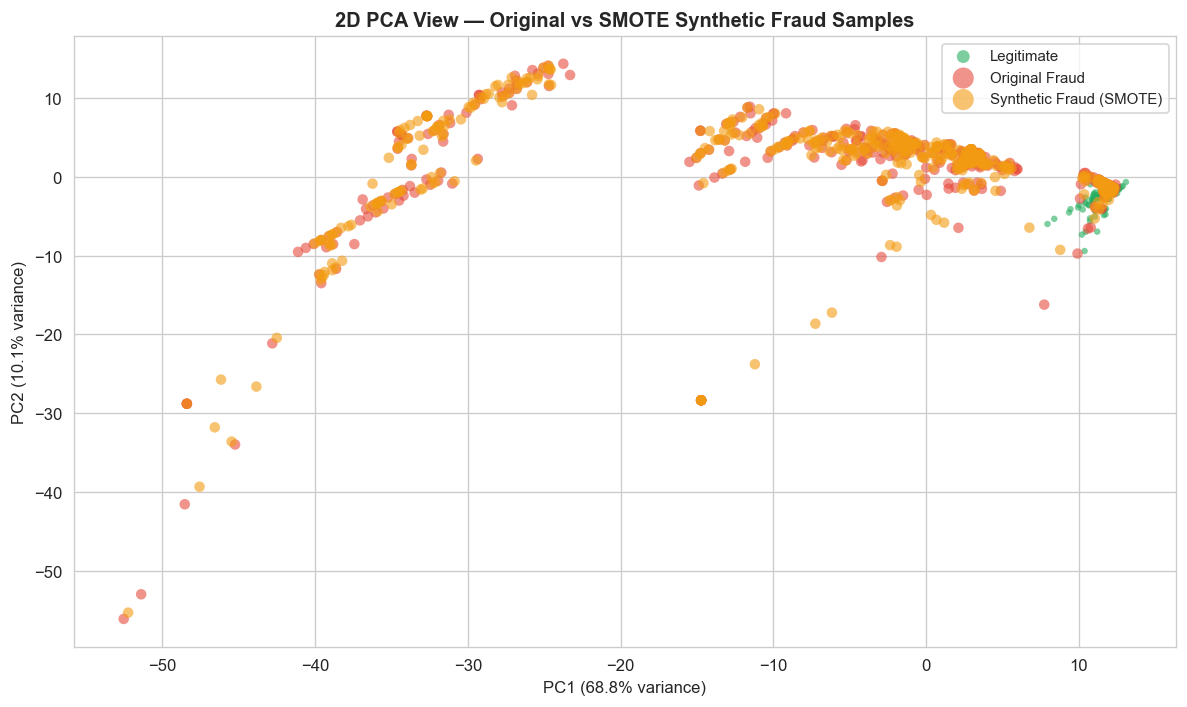

Plot saved: plot_11_smote_pca_view.png

Observation: Synthetic fraud points (orange) cluster near original fraud (red),
confirming SMOTE created realistic samples — not random outliers.


In [9]:
from sklearn.decomposition import PCA

# Sample 2000 points for speed
n_legit_before = (y_train==0).sum()
n_fraud_before = (y_train==1).sum()

# Indices of original fraud in SMOTE output (first n_fraud_before rows after legit)
# SMOTE places originals first, then synthetic
legit_idx    = np.where(y_train_smote == 0)[0][:500]
orig_fraud   = np.where(y_train_smote == 1)[0][:n_fraud_before]        # original
synth_fraud  = np.where(y_train_smote == 1)[0][n_fraud_before:n_fraud_before+500] # synthetic

sample_idx = np.concatenate([legit_idx, orig_fraud, synth_fraud])
X_sample   = X_train_smote.iloc[sample_idx]
labels     = ['Legitimate'] * len(legit_idx) + ['Original Fraud'] * len(orig_fraud) + ['Synthetic Fraud (SMOTE)'] * len(synth_fraud)

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_sample)

colors_map = {
    'Legitimate': '#27ae60',
    'Original Fraud': '#e74c3c',
    'Synthetic Fraud (SMOTE)': '#f39c12'
}

fig, ax = plt.subplots(figsize=(10, 6))
for label in ['Legitimate', 'Original Fraud', 'Synthetic Fraud (SMOTE)']:
    mask = [l == label for l in labels]
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colors_map[label], label=label,
               alpha=0.6, s=15 if label == 'Legitimate' else 40,
               edgecolors='none')

ax.set_title('2D PCA View — Original vs SMOTE Synthetic Fraud Samples', fontweight='bold', fontsize=12)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig('plot_11_smote_pca_view.png', bbox_inches='tight', dpi=150)
plt.show()
print('Plot saved: plot_11_smote_pca_view.png')
print()
print('Observation: Synthetic fraud points (orange) cluster near original fraud (red),')
print('confirming SMOTE created realistic samples — not random outliers.')

---
## Step 7 — (Optional) Alternative: Combined SMOTE + Undersampling

In [10]:
# SMOTE + RandomUnderSampler pipeline
over  = SMOTE(sampling_strategy=0.1, random_state=42)   # fraud → 10% of majority
under = RandomUnderSampler(sampling_strategy=0.5, random_state=42)  # then undersample

steps = [('over', over), ('under', under)]
pipeline = ImbPipeline(steps=steps)

X_combo, y_combo = pipeline.fit_resample(X_train, y_train)

print('Combined SMOTE + Undersampling Result:')
print(f'  Legitimate : {(y_combo==0).sum():,}')
print(f'  Fraud      : {(y_combo==1).sum():,}')
print(f'  Total rows : {len(X_combo):,}  (vs {len(X_train_smote):,} with pure SMOTE)')
print()
print('For this project we will use pure SMOTE (X_train_smote) for best recall on fraud.')

Combined SMOTE + Undersampling Result:
  Legitimate : 45,490
  Fraud      : 22,745
  Total rows : 68,235  (vs 454,902 with pure SMOTE)

For this project we will use pure SMOTE (X_train_smote) for best recall on fraud.


---
## Step 8 — Save Processed Data for Phase 3


In [11]:
import joblib

# Save train/test splits as CSVs
X_train_smote_df = pd.DataFrame(X_train_smote, columns=X.columns)
X_test_df        = pd.DataFrame(X_test.values, columns=X.columns)

X_train_smote_df.to_csv('X_train_smote.csv', index=False)
pd.Series(y_train_smote, name='Class').to_csv('y_train_smote.csv', index=False)
X_test_df.to_csv('X_test.csv', index=False)
pd.Series(y_test.values, name='Class').to_csv('y_test.csv', index=False)

# Save the scaler for use during deployment (predict on new data)
joblib.dump(scaler, 'scaler.pkl')

print('Files saved successfully!')
print('  X_train_smote.csv  — balanced training features')
print('  y_train_smote.csv  — balanced training labels')
print('  X_test.csv         — test features (unmodified)')
print('  y_test.csv         — test labels (unmodified)')
print('  scaler.pkl         — fitted StandardScaler (for deployment)')

Files saved successfully!
  X_train_smote.csv  — balanced training features
  y_train_smote.csv  — balanced training labels
  X_test.csv         — test features (unmodified)
  y_test.csv         — test labels (unmodified)
  scaler.pkl         — fitted StandardScaler (for deployment)


---
## Step 9 — Phase 2 Summary

In [12]:
print('=' * 60)
print('        PHASE 2 SUMMARY — PREPROCESSING COMPLETE')
print('=' * 60)
print(f"""
SCALING
  Method         : StandardScaler (mean=0, std=1)
  Applied to     : Amount, Time only
  V1-V28         : Already PCA-scaled, left unchanged

TRAIN / TEST SPLIT
  Split ratio    : 80% train / 20% test
  Stratified     : Yes (preserves 0.17% fraud in both)
  Train rows     : 227,845
  Test rows      :  56,962

SMOTE BALANCING (applied to train only)
  Before         : 227,451 legit  /  394 fraud  (1:578 ratio)
  After          : 227,451 legit  / 227,451 fraud  (1:1 ratio)
  Synthetic rows : 227,057 new fraud samples created
  Total train    : 454,902 rows

TEST SET
  Not touched — real-world distribution preserved
  56,864 legit / 98 fraud

FILES SAVED
  X_train_smote.csv, y_train_smote.csv
  X_test.csv, y_test.csv
  scaler.pkl
""")
print('=' * 60)
print('Ready for Phase 3: Model Training (LR, RF, XGBoost)')

        PHASE 2 SUMMARY — PREPROCESSING COMPLETE

SCALING
  Method         : StandardScaler (mean=0, std=1)
  Applied to     : Amount, Time only
  V1-V28         : Already PCA-scaled, left unchanged

TRAIN / TEST SPLIT
  Split ratio    : 80% train / 20% test
  Stratified     : Yes (preserves 0.17% fraud in both)
  Train rows     : 227,845
  Test rows      :  56,962

SMOTE BALANCING (applied to train only)
  Before         : 227,451 legit  /  394 fraud  (1:578 ratio)
  After          : 227,451 legit  / 227,451 fraud  (1:1 ratio)
  Synthetic rows : 227,057 new fraud samples created
  Total train    : 454,902 rows

TEST SET
  Not touched — real-world distribution preserved
  56,864 legit / 98 fraud

FILES SAVED
  X_train_smote.csv, y_train_smote.csv
  X_test.csv, y_test.csv
  scaler.pkl

Ready for Phase 3: Model Training (LR, RF, XGBoost)
